# Research Model Training / News Integrated

Arabica Coffee C **five-trading-day return prediction** using Yahoo price history, released COT positioning, coffee-region weather, and text-derived news features.

This companion retains the original workflow and prediction console. It uses the saved all-input model and local daily/weekly GDELT summaries. The evaluated news addition did not improve accuracy; the comparison below reports that result explicitly.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

ROOT = Path.cwd().resolve()
assert (ROOT / 'ResearchModelTraining.ipynb').exists(), 'Start the notebook from the repository root.'
os.environ['MPLCONFIGDIR'] = str(ROOT / 'Scripts/project/artifacts/.matplotlib')
sys.path.insert(0, str(ROOT / 'Scripts/project/scripts'))
import pandas as pd
from IPython.display import Image, display
from threadpoolctl import threadpool_limits
THREAD_LIMIT = threadpool_limits(limits=1)

OUTPUTS_DIR = ROOT / 'Scripts/project/artifacts/outputs'
PLOTS_DIR = ROOT / 'Scripts/project/artifacts/plots'
MODELS_DIR = ROOT / 'Scripts/project/artifacts/models'
DATA_PATH = ROOT / 'data/centralData/arabica_ml_model_ready.csv'
MODEL_PATH = MODELS_DIR / 'arabica_all_inputs_news_model.joblib'
print('Local workspace:', ROOT.name)

Local workspace: ArabicaFutures


## 1. Data Check

In [2]:
ready = pd.read_csv(DATA_PATH, parse_dates=['Date'], low_memory=False)
required = [DATA_PATH,
    OUTPUTS_DIR / 'gdelt_coffee_events_2000_2026_daily_summary.csv',
    OUTPUTS_DIR / 'gdelt_coffee_events_2000_2026_weekly_summary.csv']
assert all(path.exists() for path in required), 'A required local input is missing.'
display(pd.DataFrame({'Input': [str(p.relative_to(ROOT)) for p in required],
                      'Available': [p.exists() for p in required]}))
print(f'{len(ready):,} market rows | {ready.Date.min():%Y-%m-%d} to {ready.Date.max():%Y-%m-%d}')

,Input,Available
0,data/centralData/arabica_ml_model_ready.csv,True
1,Scripts/project/artifacts/outputs/gdelt_coffee...,True
2,Scripts/project/artifacts/outputs/gdelt_coffee...,True


6,690 market rows | 2000-01-03 to 2026-09-09


## 2. Train the All-Input Model

The saved model is loaded by default. Set `RETRAIN = True` to reproduce the paired training run using only local data. Learner selection uses validation RMSE; five-session purges separate training, validation and test labels. The final refit is stored separately from evaluation weights.

In [3]:
RETRAIN = False
if RETRAIN:
    subprocess.run([sys.executable, 'Scripts/project/scripts/train_all_inputs_news_model.py'], cwd=ROOT, check=True)
assert MODEL_PATH.exists(), 'Set RETRAIN = True to create the local model bundle.'
metrics = json.loads((OUTPUTS_DIR / 'arabica_all_inputs_news_metrics.json').read_text())
comparison = pd.read_csv(OUTPUTS_DIR / 'arabica_all_inputs_news_comparison.csv')
display(pd.DataFrame({'Source': list(metrics['source_feature_counts']),
                      'Feature count': list(metrics['source_feature_counts'].values())}))
print('Target:', metrics['target_formula'])
print('Model:', metrics['learner'])

,Source,Feature count
0,yahoo_price,31
1,cot_positioning,46
2,weather,144
3,news,9
4,news_text_subset,2


Target: Close[t+5] / Close[t] - 1
Model: hist_gradient_boosting


## 3. Compare Metrics

In [4]:
display(comparison.style.format({'rmse': '{:.4%}', 'mae': '{:.4%}',
    'directional_accuracy': '{:.2%}', 'r2': '{:.4f}'}))
print('Selected feature variant on validation:', metrics['selected_variant_by_validation'])

,phase,variant,learner,rows,mae,rmse,r2,directional_accuracy
0,validation,without_news,hist_gradient_boosting,998,4.0682%,5.4227%,-0.1694,50.40%
1,test,without_news,hist_gradient_boosting,1003,4.3304%,5.5055%,-0.0695,50.65%
2,validation,structured_news,hist_gradient_boosting,998,4.0835%,5.4441%,-0.1787,49.60%
3,test,structured_news,hist_gradient_boosting,1003,4.3157%,5.5111%,-0.0717,50.55%
4,validation,all_inputs,hist_gradient_boosting,998,4.0835%,5.4441%,-0.1787,49.60%
5,test,all_inputs,hist_gradient_boosting,1003,4.3157%,5.5111%,-0.0717,50.55%


Selected feature variant on validation: without_news


In [5]:
delta = metrics['news_delta_vs_without_news']
display(pd.DataFrame([
    {'Measure': 'Direction accuracy change (percentage points)', 'Change': delta['directional_accuracy_delta_pp']},
    {'Measure': 'RMSE relative change (%)', 'Change': delta['rmse_relative_change_pct']},
    {'Measure': 'MAE change (return units)', 'Change': delta['mae_delta']},
]))
print(metrics['conclusion'])

,Measure,Change
0,Direction accuracy change (percentage points),-0.099701
1,RMSE relative change (%),0.102710
2,MAE change (return units),-0.000147


Adding news did not improve both test RMSE and direction accuracy; see separate metric changes.


In [6]:
yearly = pd.DataFrame([
    {'Year': year, 'Variant': variant, **values}
    for year, variants in metrics['yearly_test_metrics'].items()
    for variant, values in variants.items()
])
display(yearly[['Year', 'Variant', 'rows', 'rmse', 'directional_accuracy']].style.format(
    {'rmse': '{:.3%}', 'directional_accuracy': '{:.2%}'}))

,Year,Variant,rows,rmse,directional_accuracy
0,2022,without_news,81,5.455%,37.04%
1,2022,structured_news,81,5.349%,37.04%
2,2022,all_inputs,81,5.349%,37.04%
3,2023,without_news,251,4.789%,56.18%
4,2023,structured_news,251,4.823%,51.00%
5,2023,all_inputs,251,4.823%,51.00%
6,2024,without_news,252,5.338%,46.43%
7,2024,structured_news,252,5.337%,48.02%
8,2024,all_inputs,252,5.337%,48.02%
9,2025,without_news,252,6.090%,52.78%


## 4. News Impact Diagnostics

News impact here means the difference between separately fitted with-news and without-news models, not causal attribution. Structured event indicators and simple disruption/coffee text counts are delayed six price-calendar sessions because the historical event selection used subsequent five-session returns. Price-response and retrospective impact scores are excluded.

In [7]:
display(pd.DataFrame(metrics['features_used_by_fitted_model']))
display(pd.DataFrame({'News input': metrics['source_features']['news']}))
print('Paired block-bootstrap intervals:', metrics['news_bootstrap_vs_without_news'])
print('The earlier 61.35% direction result is withdrawn because it contained future-price information.')

,evaluation,production
yahoo_price,24,21
cot_positioning,42,42
weather,99,101
news,7,8
news_text_subset,0,1


,News input
0,news_daily_event_count_log_5d
1,news_daily_bull_minus_bear_share_5d
2,news_weekly_event_count_log
3,news_weekly_bull_minus_bear_share
4,news_weekly_direction_concentration
5,news_weekly_explicit_coffee_share
6,news_weekly_mean_event_intensity
7,news_weekly_text_disruption
8,news_weekly_text_coffee


Paired block-bootstrap intervals: {'reference': 'without_news', 'block_sessions': 20, 'repetitions': 1000, 'positive_means_news_improvement': True, 'rmse_reduction_95pct_interval': [-0.0006964096747617247, 0.0005225096100262911], 'directional_accuracy_gain_95pct_interval': [-0.03090727816550349, 0.029935194416749727]}
The earlier 61.35% direction result is withdrawn because it contained future-price information.


## 5. Yahoo Real Price Comparison

The following table uses pre-test model weights and the same 1,003 held-out dates. Price-level forecasts are derived from predicted returns. These historical test results are exploratory, since this holdout has been inspected previously.

In [8]:
predictions = pd.read_csv(OUTPUTS_DIR / 'arabica_all_inputs_news_holdout_predictions.csv', parse_dates=['Date'])
predictions['actual_target_close_5d'] = predictions.Close * (1 + predictions.target_return_5d)
for variant in ['without_news', 'structured_news', 'all_inputs']:
    predictions[f'{variant}_predicted_close_5d'] = predictions.Close * (1 + predictions[f'{variant}_predicted_return_5d'])
predictions['news_model_delta'] = predictions.all_inputs_predicted_return_5d - predictions.without_news_predicted_return_5d
display(predictions.tail(10))

,Date,Close,target_return_5d,without_news_predicted_return_5d,structured_news_predicted_return_5d,all_inputs_predicted_return_5d,actual_target_close_5d,without_news_predicted_close_5d,structured_news_predicted_close_5d,all_inputs_predicted_close_5d,news_model_delta
993,2026-08-19,359.500000,-0.005285,-0.004201,-0.001607,-0.001607,357.600006,357.989717,358.922453,358.922453,0.002595
994,2026-08-20,363.600006,-0.059681,-0.022723,-0.018574,-0.018574,341.899994,355.337782,356.846424,356.846424,0.004149
995,2026-08-21,358.750000,-0.035958,0.002876,0.000281,0.000281,345.850006,359.781730,358.850717,358.850717,-0.002595
996,2026-08-24,377.750000,-0.089610,-0.013784,-0.013149,-0.013149,343.899994,372.542953,372.783153,372.783153,0.000636
997,2026-08-25,371.399994,-0.078487,0.009032,0.004448,0.004448,342.250000,374.754355,373.052142,373.052142,-0.004583
998,2026-08-26,357.600006,-0.081656,0.002774,0.003389,0.003389,328.399994,358.591899,358.811997,358.811997,0.000615
999,2026-08-27,341.899994,-0.051331,0.003757,0.007113,0.007113,324.350006,343.184540,344.331854,344.331854,0.003356
1000,2026-08-28,345.850006,-0.062455,0.000307,0.006137,0.006137,324.250000,345.956133,347.972514,347.972514,0.005830
1001,2026-08-31,343.899994,-0.074004,-0.001068,0.002332,0.002332,318.450012,343.532606,344.701811,344.701811,0.003400
1002,2026-09-01,342.250000,-0.067348,0.002511,0.004761,0.004761,319.200012,343.109485,343.879565,343.879565,0.002250


In [9]:
display(predictions[['Date', 'target_return_5d', 'without_news_predicted_return_5d',
    'all_inputs_predicted_return_5d', 'news_model_delta']].tail(15).style.format({
    'target_return_5d': '{:+.2%}', 'without_news_predicted_return_5d': '{:+.2%}',
    'all_inputs_predicted_return_5d': '{:+.2%}', 'news_model_delta': '{:+.3%}'}))

,Date,target_return_5d,without_news_predicted_return_5d,all_inputs_predicted_return_5d,news_model_delta
988,2026-08-12 00:00:00,+5.70%,-1.16%,-0.16%,+1.006%
989,2026-08-13 00:00:00,+9.16%,-1.28%,-1.05%,+0.235%
990,2026-08-14 00:00:00,+6.11%,-0.92%,-0.63%,+0.285%
991,2026-08-17 00:00:00,+9.46%,-1.07%,-1.00%,+0.062%
992,2026-08-18 00:00:00,+2.20%,-1.60%,-1.52%,+0.081%
993,2026-08-19 00:00:00,-0.53%,-0.42%,-0.16%,+0.259%
994,2026-08-20 00:00:00,-5.97%,-2.27%,-1.86%,+0.415%
995,2026-08-21 00:00:00,-3.60%,+0.29%,+0.03%,-0.260%
996,2026-08-24 00:00:00,-8.96%,-1.38%,-1.31%,+0.064%
997,2026-08-25 00:00:00,-7.85%,+0.90%,+0.44%,-0.458%


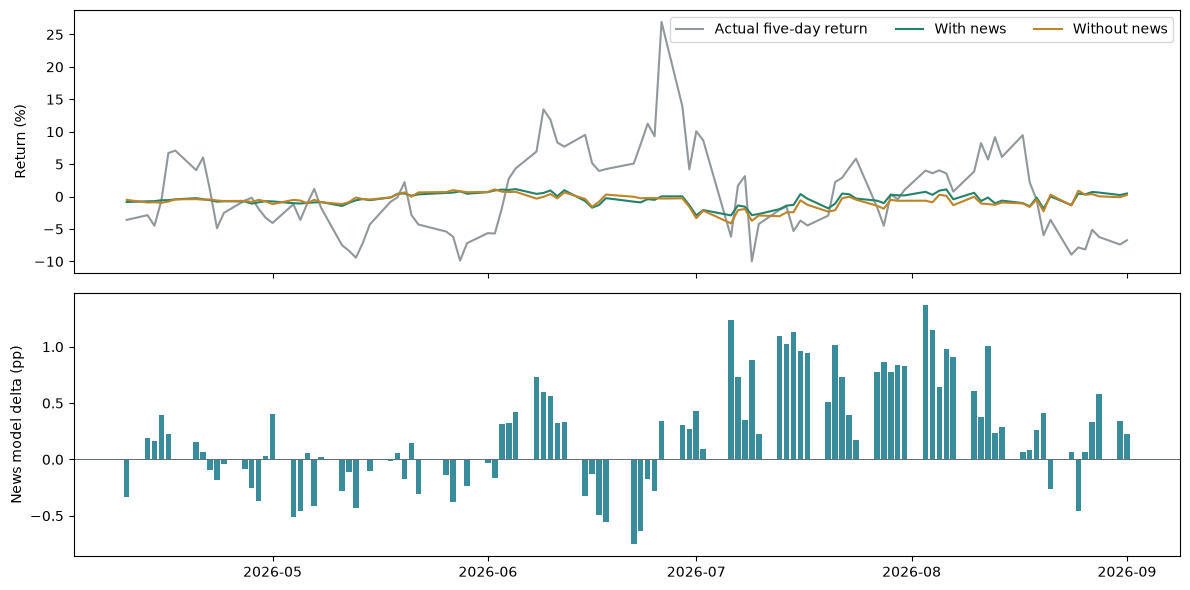

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
recent = predictions.tail(100)
axes[0].plot(recent.Date, recent.target_return_5d * 100, color='#626c72', label='Actual five-day return', alpha=0.7)
axes[0].plot(recent.Date, recent.all_inputs_predicted_return_5d * 100, color='#23826a', label='With news')
axes[0].plot(recent.Date, recent.without_news_predicted_return_5d * 100, color='#be8428', label='Without news')
axes[0].set_ylabel('Return (%)')
axes[0].legend(ncols=3)
axes[1].bar(recent.Date, recent.news_model_delta * 100, color='#398c9c')
axes[1].set_ylabel('News model delta (pp)')
axes[1].axhline(0, color='#626c72', linewidth=0.7)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'arabica_news_holdout_return_comparison.png', dpi=140)
display(fig)
plt.close(fig)

## 6. Visual Checks

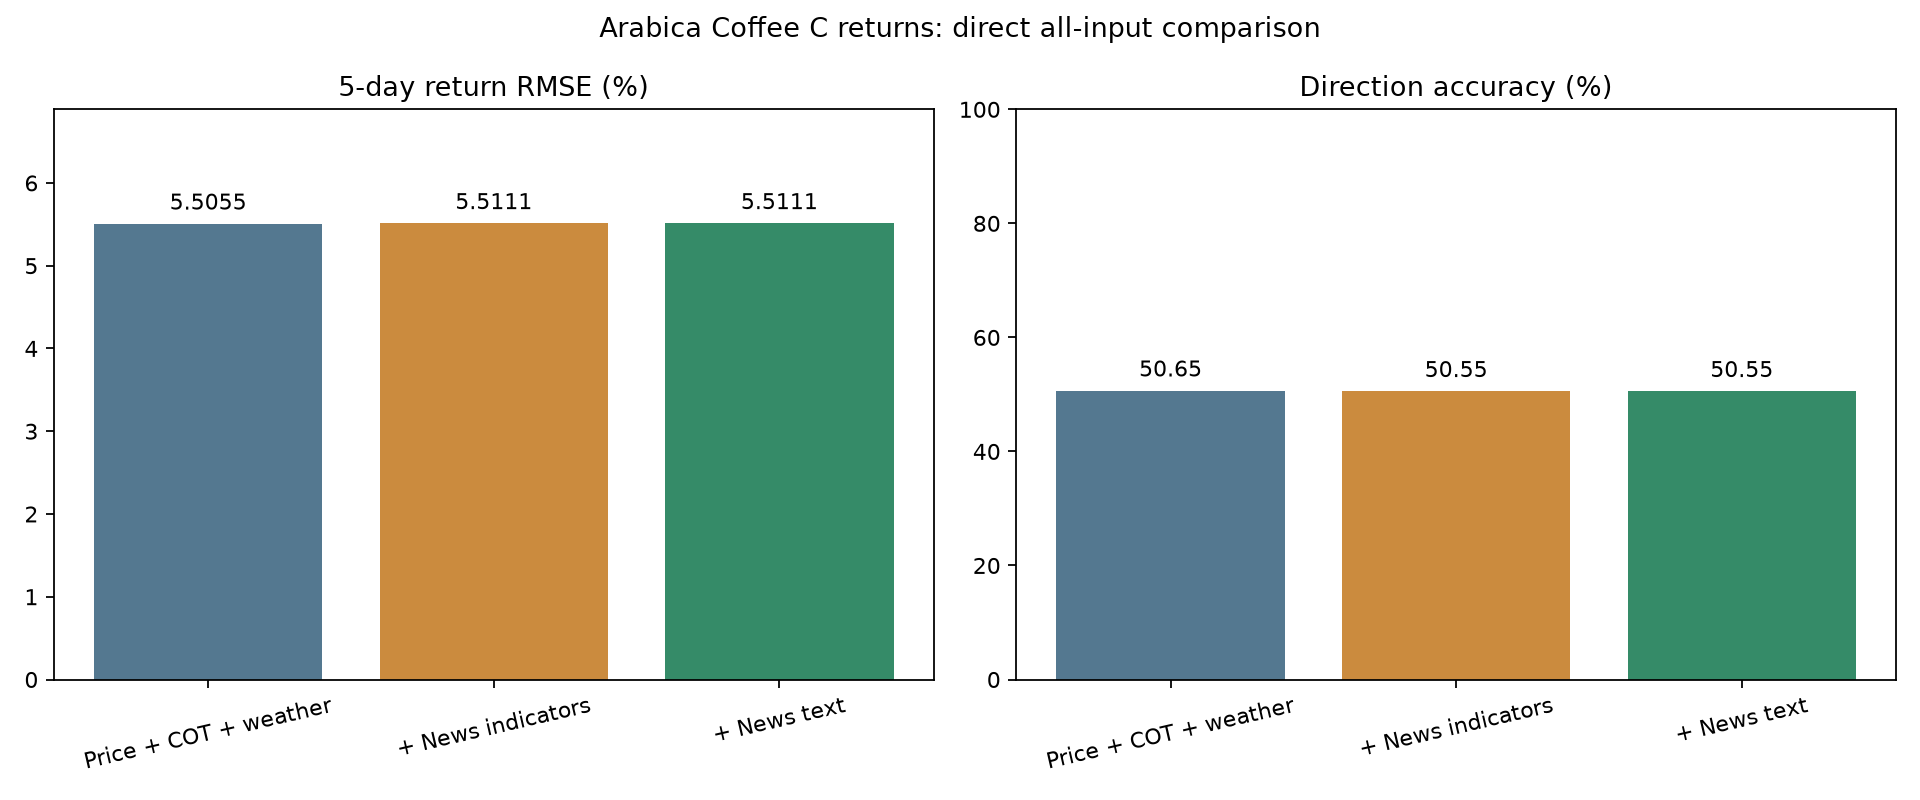

In [11]:
display(Image(filename=str(PLOTS_DIR / 'arabica_all_inputs_news_evaluation.png')))

## 7. Artifact Check

In [12]:
artifacts = [MODEL_PATH, OUTPUTS_DIR / 'arabica_all_inputs_news_metrics.json',
    OUTPUTS_DIR / 'arabica_all_inputs_news_holdout_predictions.csv',
    OUTPUTS_DIR / 'arabica_all_inputs_news_latest_predictions.csv']
assert all(path.exists() for path in artifacts)
display(pd.DataFrame({'Artifact': [str(path.relative_to(ROOT)) for path in artifacts],
                      'Present': [path.exists() for path in artifacts]}))

,Artifact,Present
0,Scripts/project/artifacts/models/arabica_all_i...,True
1,Scripts/project/artifacts/outputs/arabica_all_...,True
2,Scripts/project/artifacts/outputs/arabica_all_...,True
3,Scripts/project/artifacts/outputs/arabica_all_...,True


## Prediction Console

The familiar Inputs, Latest Prediction, Dashboard and Context tabs now include a **News Impact** tab. Latest refit uses the final all-input model; Holdout replay uses the saved pre-test models. Both modes compare news against the price/COT/weather baseline. Future target dates beyond the observed calendar are weekday estimates.

In [13]:
from news_prediction_console import create_console, DASHBOARD_PATH
console = create_console()
display(console.tabs)
console.run()
assert console.last_error is None

## Saved News-Integrated Dashboard

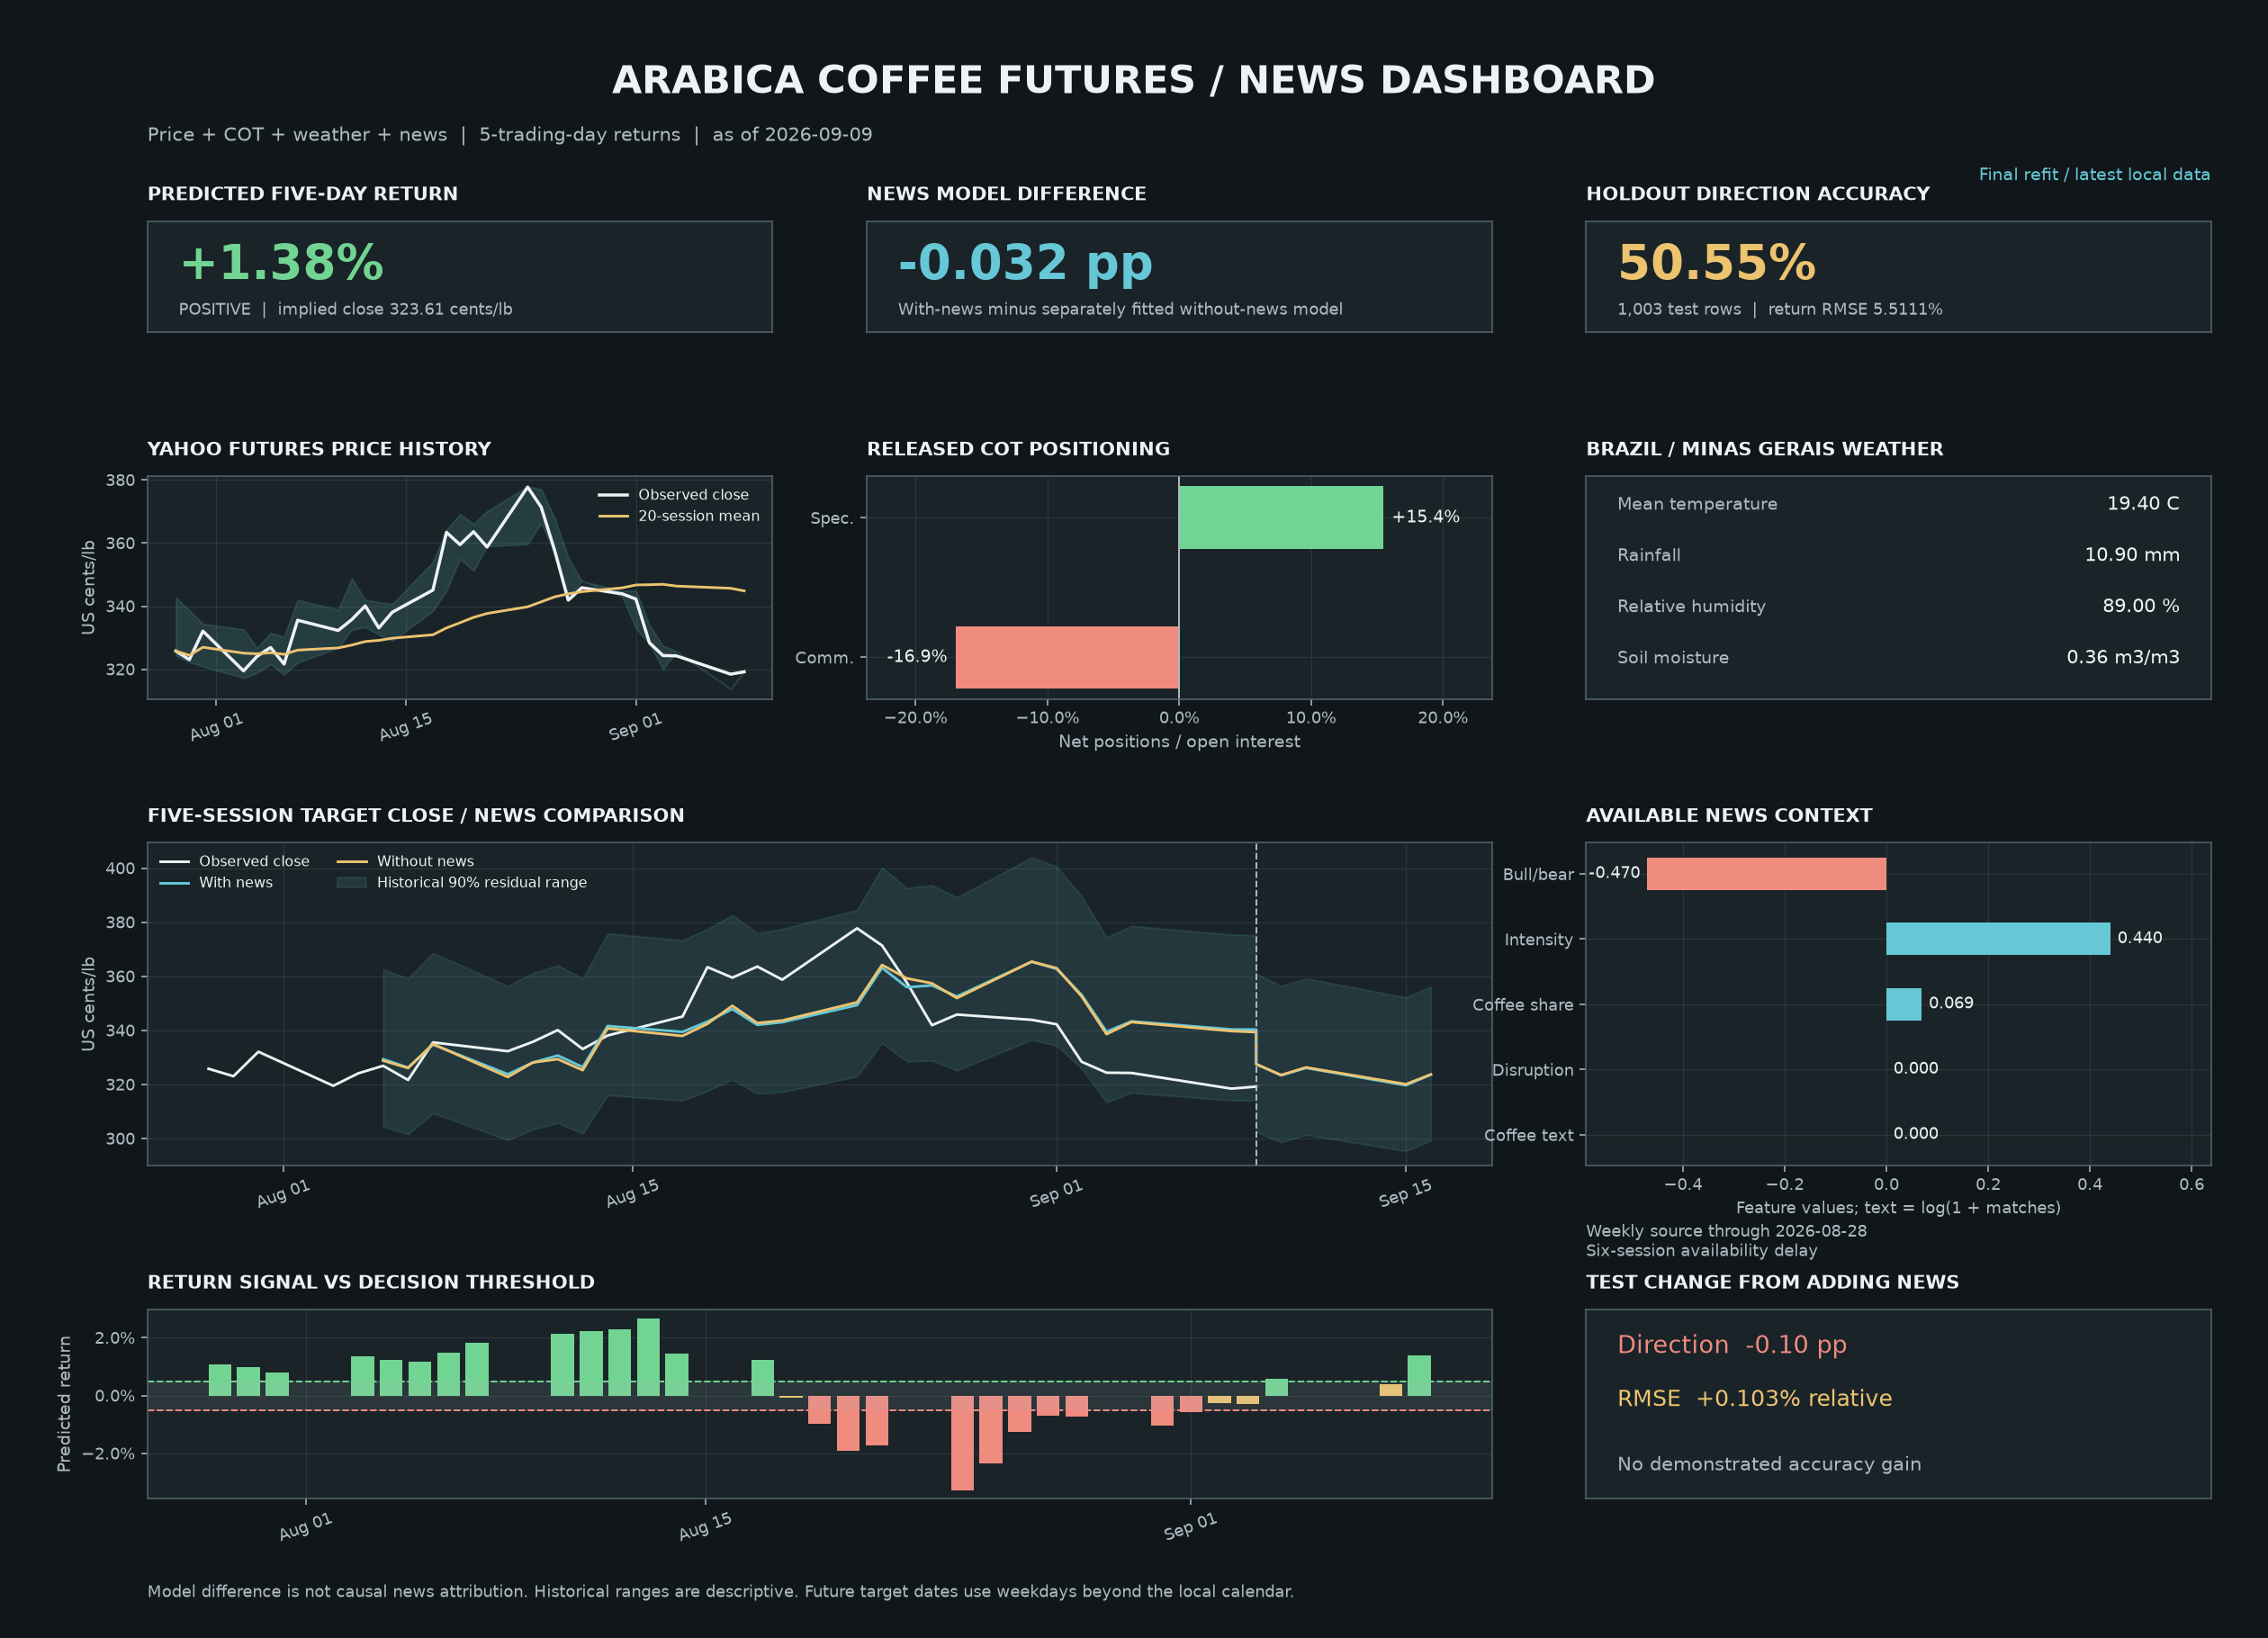

Dashboard: Scripts/project/artifacts/plots/latest_arabica_news_prediction_console.png
Predictions: Scripts/project/artifacts/outputs/latest_arabica_news_console_predictions.csv


In [14]:
display(Image(filename=str(DASHBOARD_PATH)))
print('Dashboard:', DASHBOARD_PATH.relative_to(ROOT))
print('Predictions:', 'Scripts/project/artifacts/outputs/latest_arabica_news_console_predictions.csv')